In [1]:
import requests_cache
requests_cache.install_cache("cache.sqlite", backend="sqlite")
import requests # Making web requests
import pandas as pd # Tabular data operations
import geopandas as gpd # Geospatial data
import numpy as np
import folium
from dotenv import load_dotenv
load_dotenv()
import os
from tqdm.auto import tqdm
from pprint import pprint
import statsmodels.formula.api as smf
pd.set_option("display.max_columns", None)

In [2]:
results = []
s = requests.Session()
s.headers.update({"X-API-Key": os.getenv("HEALTHPOINT_API_KEY")})
r = s.get("https://api.healthpointapi.com/baseR4/HealthcareService?branch-code=pharmacy&_count=200").json() # Max 200 per page
results.extend(r["entry"])
for page in tqdm(range(200, r["total"], 200)):
    next_url = r["link"][1]["url"]
    r = s.get(next_url).json()
    results.extend(r["entry"])

  0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
locations = []
for r in tqdm(results):
    r = r["resource"]
    hours = 0
    for day in r.get("availableTime", [])[:7]:
        hours += (pd.Timedelta(day["availableEndTime"]) - pd.Timedelta(day["availableStartTime"])).seconds / 60 / 60
    location = {
        "name": r["name"],
        "openHoursPerWeek": hours,
        "ECP": False,
    }
    for e in r["extension"][0]["extension"]:
        if e["url"] == "dhb-region":
            location["dhb-region"] = e["valueString"]
        if e["url"] == "services-provided":
            for service in e["extension"]:
                if service.get("valueString") == 'Emergency contraceptive pill (ECP) | Morning after pill':
                    location["ECP"] = True
        for ee in e.get("extension", []):
            if ee["url"] == "coordinates":
                for eee in ee["extension"]:
                    if eee["url"] == "latitude":
                        location["latitude"] = float(eee["valueDecimal"])
                    if eee["url"] == "longitude":
                        location["longitude"] = float(eee["valueDecimal"])
    if "latitude" not in location or "longitude" not in location:
        print("No coordinates for", r["name"])
        continue
    locations.append(location)

df = pd.DataFrame(locations)
# These are either hospital pharmacies or inpatient services
# or other services that are not relevant to the public
df = df[~df.name.str.contains("Gisborne Hospital Pharmacy|Tauranga Hospital|Hawke's Bay Hospital Pharmacy|Inpatient|Pharmacy Services", case=False)]
display(df)
df.ECP.value_counts()

  0%|          | 0/1102 [00:00<?, ?it/s]

No coordinates for ZOOM Pharmacy
No coordinates for NorthWest 7 Day Pharmacy
No coordinates for Chemist Warehouse Online – Covid Antivirals
No coordinates for Wyndham Prescription Centre
No coordinates for Unichem Dennis Hanna Pharmacy
No coordinates for PillDrop Pharmacy
No coordinates for Bargain Chemist Archers
No coordinates for Chemist Warehouse Pukekohe - The Zone


,name,openHoursPerWeek,ECP,dhb-region,latitude,longitude
0,Collingwood Street Pharmacy,40.00,False,Nelson Marlborough,-41.274967,173.286599
1,Caversham Pharmacy,42.50,True,Southern,-45.896328,170.480630
2,Lifeline Pharmacy,57.00,True,Central Auckland,-36.941998,174.841796
3,John's Stoke Pharmacy,40.00,True,Nelson Marlborough,-41.312011,173.233769
4,Hillcrest Central Pharmacy,50.00,True,Waitematā DHB,-36.799096,174.730474
...,...,...,...,...,...,...
1089,Unichem Onerahi Pharmacy,48.50,True,Northland,-35.755039,174.368105
1090,Nawton Pharmacy,43.75,True,Waikato,-37.780461,175.237338
1091,Hillmorton Pharmacy,45.00,True,Canterbury,-43.554287,172.594106
1092,Woolworths Pharmacy Greville Road,59.00,True,Waitematā DHB,-36.730737,174.722800


ECP
True     1010
False      71
Name: count, dtype: int64

In [4]:
df["dhb-region"].replace({'Bay of Plenty': 'Bay of Plenty',
 'CM Health': 'Counties Manukau',
 'Canterbury': 'Canterbury',
 'Central Auckland': 'Auckland',
 'Hawkes Bay': "Hawke's Bay",
 'Hutt': 'Capital, Coast and Hutt Valley',
 'Lakes': 'Lakes',
 'MidCentral': 'MidCentral',
 'Nelson Marlborough': 'Nelson Marlborough',
 'Northland': 'Northland',
 'South Canterbury': 'South Canterbury',
 'Southern': 'Southern',
 'Tairawhiti': 'Tairāwhiti',
 'Taranaki': 'Taranaki',
 'Waikato': 'Waikato',
 'Wairarapa': 'Wairarapa',
 'Waitematā DHB': 'Waitematā',
 'Wellington': 'Capital, Coast and Hutt Valley', # Note this merges Wellington and Hutt Valley
 'West Coast': 'West Coast',
 'Whanganui': 'Whanganui'
}, inplace=True)

/tmp/ipykernel_1066009/3370469065.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["dhb-region"].replace({'Bay of Plenty': 'Bay of Plenty',


In [5]:
df["depot"] = df.name.str.contains("Depot", case=False).replace({True: "Depot", False: "Community"})
depot_by_DHB = df.groupby("dhb-region").depot.value_counts().unstack().fillna(0).astype(int).T
depot_by_DHB

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
depot,,,,,,,,,,,,,,,,,,,
Community,133,59,137,88,119,36,21,31,30,35,11,82,7,26,86,8,133,4,15
Depot,0,0,1,0,0,0,1,1,2,1,0,3,9,1,0,0,0,0,1


In [6]:
openHoursStats = df.groupby("dhb-region").openHoursPerWeek.describe().T
openHoursStats.index = "Open hours per week " + openHoursStats.index
openHoursStats

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Open hours per week count,133.000000,59.000000,138.000000,88.000000,119.000000,36.000000,22.000000,32.000000,32.000000,36.000000,11.000000,85.000000,16.000000,27.000000,86.000000,8.000000,133.000000,4.000000,16.000000
Open hours per week mean,56.508145,51.563559,54.070652,53.980114,56.334034,51.951389,53.920455,47.611979,50.468750,49.027778,51.090909,51.690196,23.250000,49.444444,51.360465,53.687500,58.877820,46.750000,49.062500
Open hours per week std,14.928614,11.391693,14.117210,11.569022,17.118056,11.207430,15.634856,7.307616,10.053035,12.058456,10.145980,13.194908,28.439995,11.254344,13.132952,9.724555,14.005837,1.848423,9.012722
Open hours per week min,20.000000,40.000000,0.000000,35.000000,0.000000,40.000000,39.000000,40.000000,40.000000,25.500000,42.500000,34.166667,0.000000,37.500000,37.500000,42.000000,40.000000,45.000000,40.000000
Open hours per week 25%,46.000000,44.875000,45.000000,45.875000,45.000000,44.687500,45.000000,42.500000,45.000000,43.750000,45.250000,42.500000,0.000000,43.500000,44.250000,46.250000,48.500000,45.375000,42.500000
Open hours per week 50%,52.000000,48.500000,48.750000,51.500000,51.500000,49.000000,46.375000,45.000000,47.750000,48.000000,48.000000,47.500000,0.000000,48.000000,47.875000,52.250000,54.000000,46.500000,45.000000
Open hours per week 75%,63.000000,54.500000,59.000000,57.000000,65.500000,56.125000,57.750000,48.000000,52.500000,49.062500,52.750000,57.000000,47.500000,48.500000,51.000000,62.250000,67.500000,47.875000,54.250000
Open hours per week max,101.000000,91.000000,91.000000,91.000000,105.000000,91.000000,91.000000,69.000000,84.000000,91.000000,75.000000,94.500000,73.000000,91.000000,98.000000,66.000000,101.500000,49.000000,70.500000


In [7]:
ECP = df.groupby(["dhb-region"]).ECP.value_counts().unstack().fillna(0).astype(int).rename(columns={True: "ECP", False: "No ECP"}).T.sort_index()
ECP

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
ECP,,,,,,,,,,,,,,,,,,,
ECP,126,56,130,83,115,32,20,31,29,33,10,78,7,25,84,8,126,4,13
No ECP,7,3,8,5,4,4,2,1,3,3,1,7,9,2,2,0,7,0,3


In [8]:
results = pd.concat([depot_by_DHB, openHoursStats, ECP])
results

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Community,133.000000,59.000000,137.000000,88.000000,119.000000,36.000000,21.000000,31.000000,30.000000,35.000000,11.000000,82.000000,7.000000,26.000000,86.000000,8.000000,133.000000,4.000000,15.000000
Depot,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.000000,3.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Open hours per week count,133.000000,59.000000,138.000000,88.000000,119.000000,36.000000,22.000000,32.000000,32.000000,36.000000,11.000000,85.000000,16.000000,27.000000,86.000000,8.000000,133.000000,4.000000,16.000000
Open hours per week mean,56.508145,51.563559,54.070652,53.980114,56.334034,51.951389,53.920455,47.611979,50.468750,49.027778,51.090909,51.690196,23.250000,49.444444,51.360465,53.687500,58.877820,46.750000,49.062500
Open hours per week std,14.928614,11.391693,14.117210,11.569022,17.118056,11.207430,15.634856,7.307616,10.053035,12.058456,10.145980,13.194908,28.439995,11.254344,13.132952,9.724555,14.005837,1.848423,9.012722
Open hours per week min,20.000000,40.000000,0.000000,35.000000,0.000000,40.000000,39.000000,40.000000,40.000000,25.500000,42.500000,34.166667,0.000000,37.500000,37.500000,42.000000,40.000000,45.000000,40.000000
Open hours per week 25%,46.000000,44.875000,45.000000,45.875000,45.000000,44.687500,45.000000,42.500000,45.000000,43.750000,45.250000,42.500000,0.000000,43.500000,44.250000,46.250000,48.500000,45.375000,42.500000
Open hours per week 50%,52.000000,48.500000,48.750000,51.500000,51.500000,49.000000,46.375000,45.000000,47.750000,48.000000,48.000000,47.500000,0.000000,48.000000,47.875000,52.250000,54.000000,46.500000,45.000000
Open hours per week 75%,63.000000,54.500000,59.000000,57.000000,65.500000,56.125000,57.750000,48.000000,52.500000,49.062500,52.750000,57.000000,47.500000,48.500000,51.000000,62.250000,67.500000,47.875000,54.250000
Open hours per week max,101.000000,91.000000,91.000000,91.000000,105.000000,91.000000,91.000000,69.000000,84.000000,91.000000,75.000000,94.500000,73.000000,91.000000,98.000000,66.000000,101.500000,49.000000,70.500000


In [9]:
df.to_csv("healthpoint_pharmacies_ECP.csv", index=False)

In [10]:
df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs=4326)
df

,name,openHoursPerWeek,ECP,dhb-region,latitude,longitude,depot,geometry
0,Collingwood Street Pharmacy,40.00,False,Nelson Marlborough,-41.274967,173.286599,Community,POINT (173.2866 -41.27497)
1,Caversham Pharmacy,42.50,True,Southern,-45.896328,170.480630,Community,POINT (170.48063 -45.89633)
2,Lifeline Pharmacy,57.00,True,Auckland,-36.941998,174.841796,Community,POINT (174.8418 -36.942)
3,John's Stoke Pharmacy,40.00,True,Nelson Marlborough,-41.312011,173.233769,Community,POINT (173.23377 -41.31201)
4,Hillcrest Central Pharmacy,50.00,True,Waitematā,-36.799096,174.730474,Community,POINT (174.73047 -36.7991)
...,...,...,...,...,...,...,...,...
1089,Unichem Onerahi Pharmacy,48.50,True,Northland,-35.755039,174.368105,Community,POINT (174.36811 -35.75504)
1090,Nawton Pharmacy,43.75,True,Waikato,-37.780461,175.237338,Community,POINT (175.23734 -37.78046)
1091,Hillmorton Pharmacy,45.00,True,Canterbury,-43.554287,172.594106,Community,POINT (172.59411 -43.55429)
1092,Woolworths Pharmacy Greville Road,59.00,True,Waitematā,-36.730737,174.722800,Community,POINT (174.7228 -36.73074)


In [11]:
sa2 = gpd.read_file("statistical-area-2-2023-generalised_simplified_22.3%.zip").dropna(subset="geometry")
sa2 = sa2[(sa2.SA22023__1 != "Chatham Islands") & (sa2.LAND_AREA_ > 0)].copy()
sa2

,SA22023_V1,SA22023__1,SA22023__2,LAND_AREA_,AREA_SQ_KM,Shape_Leng,geometry
0,100100,North Cape,North Cape,829.188012,829.188012,416039.151064,"MULTIPOLYGON (((1614055.808 6154067.023, 16141..."
1,100200,Rangaunu Harbour,Rangaunu Harbour,274.004295,274.004295,149089.110095,"MULTIPOLYGON (((1624166.328 6127258.658, 16243..."
3,100400,Karikari Peninsula,Karikari Peninsula,174.440751,174.440751,140149.099270,"MULTIPOLYGON (((1626838.499 6126965.133, 16270..."
4,100500,Tangonge,Tangonge,177.182117,177.182117,101466.900183,"POLYGON ((1623516.265 6119580.907, 1623492.213..."
5,100900,Rangitihi,Rangitihi,84.539982,84.539982,60636.302194,"POLYGON ((1629314.862 6117970.968, 1629371.783..."
...,...,...,...,...,...,...,...
2374,362601,Heidelberg,Heidelberg,1.308968,1.308968,5367.870180,"POLYGON ((1245892.259 4848174.153, 1245922.973..."
2375,363001,Clifton-Kew,Clifton-Kew,3.770832,3.770832,11890.253381,"POLYGON ((1243666.689 4847254.124, 1243677.447..."
2376,363100,Woodend-Greenhills,Woodend-Greenhills,173.600766,173.600766,166674.352079,"MULTIPOLYGON (((1248612.765 4823630.51, 124866..."
2378,363301,Bluff,Bluff,10.136949,10.290040,23162.004392,"POLYGON ((1244729.237 4827495.819, 1244667.973..."


In [12]:
BASE_URL = "http://osrm.auckland-cer.cloud.edu.au"

def drive(from_points, to_points):
    from_points_s = ";".join([f"{point.x},{point.y}" for point in from_points])
    from_indices = ";".join([str(i) for i in range(len(from_points))])
    to_points_s = ";".join([f"{point.x},{point.y}" for point in to_points])
    to_indices = ";".join([str(i + len(from_points)) for i in range(len(to_points))])
    result = requests.get(f"{BASE_URL}/table/v1/driving/{from_points_s};{to_points_s}?sources={from_indices}&destinations={to_indices}&annotations=duration,distance")
    return result.json()
result = drive(from_points=sa2.centroid.to_crs(epsg=4326), to_points=df[df.ECP].geometry.to_crs(epsg=4326))

In [13]:
min_indices = np.argmin(result["distances"], axis=1)
sa2["Distance to nearest ECP pharmacy (m)"] = [result["distances"][i][min_indices[i]] for i in range(len(min_indices))]
sa2["Travel time to nearest ECP pharmacy (s)"] = [result["durations"][i][min_indices[i]] for i in range(len(min_indices))]
sa2["Nearest pharmacy name"] = list(df[df.ECP].name.iloc[min_indices])
sa2["DHB"] = list(df[df.ECP]["dhb-region"].iloc[min_indices])
sa2["openHoursPerWeek"] = list(df[df.ECP].openHoursPerWeek.iloc[min_indices])

In [14]:
distance_stats = sa2.groupby("DHB")["Distance to nearest ECP pharmacy (m)"].describe().T
distance_stats.index = "Distance to nearest ECP pharmacy (m) " + distance_stats.index
distance_stats

DHB,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Distance to nearest ECP pharmacy (m) count,181.000000,109.000000,279.000000,194.000000,212.000000,88.000000,69.000000,98.000000,82.000000,99.000000,41.000000,188.000000,27.000,65.000000,229.000000,26.000000,237.000000,28.000000,43.000000
Distance to nearest ECP pharmacy (m) mean,1163.490055,6239.520183,6068.725806,2047.309794,2502.155189,6979.627273,9938.626087,7806.137755,9639.497561,12837.443434,13629.407317,11759.357447,23461.600,9124.972308,7024.758515,8764.650000,2863.366667,35973.725000,11095.237209
Distance to nearest ECP pharmacy (m) std,2403.198829,11584.158615,14321.081318,2052.190648,3983.418649,12889.553689,14896.974487,13729.594223,18838.259330,17538.473598,20898.891317,22367.944850,45904.961,15127.037721,9967.551790,11519.315858,4048.728775,43539.164798,19152.645388
Distance to nearest ECP pharmacy (m) min,4.300000,129.100000,4.000000,70.400000,75.500000,41.200000,356.000000,113.600000,204.000000,192.500000,601.300000,147.000000,472.400,99.400000,232.300000,190.600000,46.600000,1383.000000,396.200000
Distance to nearest ECP pharmacy (m) 25%,534.700000,1095.300000,848.050000,841.200000,848.025000,971.000000,1458.200000,1065.200000,1233.825000,1319.950000,1081.600000,1160.650000,1169.250,1043.400000,1141.100000,1215.825000,871.100000,3663.950000,872.250000
Distance to nearest ECP pharmacy (m) 50%,877.700000,2167.000000,1377.500000,1458.900000,1348.750000,1668.650000,2826.200000,2121.700000,2541.700000,6634.300000,2813.100000,2335.500000,1969.600,2743.000000,1930.100000,2050.250000,1487.800000,19412.350000,1847.000000
Distance to nearest ECP pharmacy (m) 75%,1246.800000,6273.200000,3446.150000,2303.450000,2077.575000,4218.050000,12733.500000,10823.250000,7539.675000,18681.800000,14430.400000,11909.825000,8912.750,11321.600000,9953.900000,10662.500000,2667.300000,56075.550000,9706.200000
Distance to nearest ECP pharmacy (m) max,29252.900000,81058.800000,102439.800000,13136.600000,31468.900000,64669.000000,62566.100000,99517.900000,99909.200000,110460.600000,82834.900000,174354.900000,170542.100,80948.100000,53966.000000,36522.200000,31436.700000,183080.200000,67686.200000


In [15]:
travel_time_stats = sa2.groupby("DHB")["Travel time to nearest ECP pharmacy (s)"].describe().T
travel_time_stats.index = "Travel time to nearest ECP pharmacy (s) " + travel_time_stats.index
travel_time_stats

DHB,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Travel time to nearest ECP pharmacy (s) count,181.000000,109.000000,279.000000,194.000000,212.000000,88.000000,69.000000,98.000000,82.000000,99.000000,41.000000,188.000000,27.000000,65.000000,229.000000,26.000000,237.000000,28.000000,43.000000
Travel time to nearest ECP pharmacy (s) mean,130.404972,599.760550,446.532616,222.924227,232.175472,548.746591,832.186957,717.390816,809.592683,928.065657,994.570732,1043.328191,1619.303704,725.924615,559.232751,818.850000,260.343038,2296.675000,785.076744
Travel time to nearest ECP pharmacy (s) std,250.620568,1015.532553,856.198767,256.549319,303.204715,1021.255363,1273.147343,1435.008837,1509.165895,1132.928251,1504.006840,2733.165618,2876.235001,1145.350155,757.330412,1228.265118,300.479494,2365.057016,1267.845701
Travel time to nearest ECP pharmacy (s) min,0.500000,11.700000,1.000000,17.000000,18.000000,7.200000,34.200000,10.200000,31.500000,27.900000,64.200000,13.700000,70.900000,16.400000,34.700000,29.500000,11.200000,162.000000,50.800000
Travel time to nearest ECP pharmacy (s) 25%,70.700000,131.500000,107.250000,101.200000,105.150000,108.300000,149.100000,118.775000,154.200000,153.700000,124.800000,130.100000,134.150000,116.000000,130.200000,127.825000,98.700000,415.475000,104.550000
Travel time to nearest ECP pharmacy (s) 50%,102.600000,222.300000,159.400000,160.500000,150.800000,180.100000,278.000000,206.450000,266.250000,517.500000,275.800000,242.500000,204.500000,298.300000,213.300000,209.850000,174.500000,1395.600000,189.200000
Travel time to nearest ECP pharmacy (s) 75%,140.600000,545.200000,318.050000,246.175000,236.175000,374.025000,940.400000,800.325000,558.025000,1225.300000,1414.600000,853.325000,720.250000,659.600000,731.100000,867.200000,293.300000,3861.600000,938.700000
Travel time to nearest ECP pharmacy (s) max,3175.500000,6458.100000,6936.500000,2591.800000,3319.400000,6643.200000,6898.400000,12067.400000,8313.500000,5851.700000,6972.800000,29712.900000,9775.500000,4894.600000,4994.600000,4286.600000,2584.200000,8630.600000,6161.400000


In [16]:
pop = pd.read_csv("2023 population by DHB.csv")
pop["Sex at birth"] = np.where(pop["CEN23_SAB_002"] == 11, "Male", "Female")
pop

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,CEN23_YEAR_001,Census year,CEN23_GEO_002,Area,CEN23_ETH_002,Ethnicity,CEN23_AGE_001,Age,CEN23_SAB_002,Sex at birth,OBS_VALUE,Observation Value,OBS_STATUS,Observation Status
0,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,4,15-19 years,11,Male,5952,NaN,NaN,NaN
1,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,4,15-19 years,22,Female,5583,NaN,NaN,NaN
2,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,5,20-24 years,11,Male,4485,NaN,NaN,NaN
3,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,5,20-24 years,22,Female,4158,NaN,NaN,NaN
4,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,6,25-29 years,11,Male,4845,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,12,55-59 years,22,Female,10938,NaN,NaN,NaN
414,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,13,60-64 years,11,Male,10818,NaN,NaN,NaN
415,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,13,60-64 years,22,Female,11208,NaN,NaN,NaN
416,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,4,65 years and over,11,Male,29445,NaN,NaN,NaN


In [17]:
pop_by_dhb = pop.pivot_table(index="Age", columns="Area", values="OBS_VALUE", aggfunc="sum")
pop_by_dhb

Area,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Age,,,,,,,,,,,,,,,,,,,
15-19 years,29301,15855,37881,30396,41766,11139,7404,11850,8922,11535,3297,24099,3597,7668,28479,2817,38886,1665,4074
20-24 years,37527,13155,38499,34866,39381,8940,6048,11385,6834,8643,2754,24738,2874,6201,26325,2127,36960,1296,3396
25-29 years,43146,15225,39876,34905,43059,10140,7017,11724,8118,9681,3420,22197,3153,6771,28254,2442,41205,1554,3819
30-34 years,42285,17964,45345,36711,48243,11493,7839,12300,9651,11547,3879,24633,3420,8145,31551,2901,49776,2043,4341
35-39 years,36138,16743,41088,33012,44163,10374,7275,11250,9582,11157,3483,22845,3153,8157,28830,2625,49908,1842,3894
40-44 years,31827,15381,37095,30894,39375,9882,6612,10350,9225,9909,3243,20589,2856,7629,26325,2781,46578,1710,3498
45-49 years,29085,15462,35862,29805,34605,10431,6729,10302,9921,10629,3507,20370,2916,7683,25233,2871,41103,1956,3747
50-54 years,29766,16638,39228,30798,35604,11526,7449,11457,11316,12726,4083,21678,3093,8274,27123,3417,41643,2481,4305
55-59 years,26631,15789,36486,28230,32448,11055,7209,11427,11445,13491,4293,21150,3033,7803,25554,3477,37284,2760,4500


In [18]:
aggregate = pop_by_dhb.loc["45-49":"65 years and over"].sum(axis=0).sort_values(ascending=False)
aggregate.name = "45 years and over"
pop_by_dhb = pd.concat([pop_by_dhb.loc[:"45-49"], aggregate.to_frame().T])
pop_by_dhb

Area,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
15-19 years,29301,15855,37881,30396,41766,11139,7404,11850,8922,11535,3297,24099,3597,7668,28479,2817,38886,1665,4074
20-24 years,37527,13155,38499,34866,39381,8940,6048,11385,6834,8643,2754,24738,2874,6201,26325,2127,36960,1296,3396
25-29 years,43146,15225,39876,34905,43059,10140,7017,11724,8118,9681,3420,22197,3153,6771,28254,2442,41205,1554,3819
30-34 years,42285,17964,45345,36711,48243,11493,7839,12300,9651,11547,3879,24633,3420,8145,31551,2901,49776,2043,4341
35-39 years,36138,16743,41088,33012,44163,10374,7275,11250,9582,11157,3483,22845,3153,8157,28830,2625,49908,1842,3894
40-44 years,31827,15381,37095,30894,39375,9882,6612,10350,9225,9909,3243,20589,2856,7629,26325,2781,46578,1710,3498
45 years and over,170892,118230,246177,181614,200421,78378,48564,80487,81048,93462,30168,146877,20694,56136,179658,24957,246435,17826,31779


In [19]:
sex_by_DHB = pop.pivot_table(index="Sex at birth", columns="Area", values="OBS_VALUE", aggfunc="sum")
sex_by_DHB

Area,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Sex at birth,,,,,,,,,,,,,,,,,,,
Female,198777,109839,246207,196926,230664,72042,46332,76728,67695,79440,25281,145005,20196,51294,177993,20931,260037,13668,27987
Male,192339,102714,239754,185472,225744,68304,44427,72618,65685,76494,24963,140973,19551,49413,171429,19719,249711,14268,26814


In [20]:
DHB = gpd.read_file("DHB_with_weighted_average_IMD18.shp.zip")
DHB = DHB[DHB.DHB2015_Co != "99"]
DHB

,DHB2015_Co,DHB2015_Na,Shape_Leng,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces,geometry
0,01,Northland,1.651929e+06,179277.0,233.0,4186.139929,4408.972314,4102.090865,3550.266454,3374.030004,2976.975702,4427.724443,4541.327783,"MULTIPOLYGON (((1714357.617 5983211.997, 17143..."
1,02,Waitemata,9.273920e+05,586419.0,766.0,2555.370481,2534.364779,2838.310897,2377.956905,3196.632655,2925.216122,2275.860630,3072.006252,"MULTIPOLYGON (((1733681.085 5898435.008, 17336..."
2,03,Auckland,7.781903e+05,468210.0,600.0,2657.051784,2612.240652,2490.958480,3543.322157,4213.631390,3095.427071,1752.652656,1556.293362,"MULTIPOLYGON (((1792135.131 5911180.463, 17921..."
3,04,Counties Manukau,6.642233e+05,538047.0,673.0,3605.304925,3163.296191,3680.218881,3357.409899,4132.371053,3840.297855,3726.701632,2394.369704,"POLYGON ((1770832.38 5917413.866, 1770841.514 ..."
4,05,Waikato,1.498296e+06,406302.0,535.0,3841.634996,3718.750059,3601.131466,3475.211550,3334.801985,3609.067494,3853.276098,3640.353028,"MULTIPOLYGON (((1857357.606 5876615.882, 18573..."
5,06,Lakes,6.236689e+05,109350.0,142.0,3932.881481,3886.664417,3705.677641,3867.164472,3342.953032,3543.913224,3955.365569,3424.880713,"POLYGON ((1888813.981 5796074.319, 1888957.483..."
6,07,Bay of Plenty,9.468737e+05,240525.0,307.0,3424.531662,3444.681902,3303.093957,3364.163106,2739.652897,3231.519414,3613.792679,3805.321123,"MULTIPOLYGON (((1881976.181 5830239.392, 18819..."
7,08,Tairawhiti,6.895486e+05,47619.0,65.0,4529.040509,4442.164777,4519.621937,4054.131859,4027.701569,3930.705664,4461.959869,3422.965917,"MULTIPOLYGON (((2039187 5703721.815, 2039193.6..."
8,09,Taranaki,5.657958e+05,117957.0,158.0,3546.936316,3622.695287,3558.354434,2691.329128,2515.897581,3463.655739,3990.581983,3657.769806,"MULTIPOLYGON (((1687624.521 5675968.386, 16876..."
9,10,Hawke's Bay,9.454397e+05,166491.0,223.0,3594.516406,3398.434267,3770.723084,3810.380597,3205.178730,3213.648594,3686.793394,2881.920356,"MULTIPOLYGON (((1941251.295 5580353.81, 194124..."


In [21]:
import rapidfuzz

mapping = {dhb: rapidfuzz.process.extractOne(dhb, sex_by_DHB.columns)[0] for dhb in DHB.DHB2015_Na}
mapping

{'Northland': 'Northland',
 'Waitemata': 'Waitematā',
 'Auckland': 'Auckland',
 'Counties Manukau': 'Counties Manukau',
 'Waikato': 'Waikato',
 'Lakes': 'Lakes',
 'Bay of Plenty': 'Bay of Plenty',
 'Tairawhiti': 'Tairāwhiti',
 'Taranaki': 'Taranaki',
 "Hawke's Bay": "Hawke's Bay",
 'Whanganui': 'Whanganui',
 'MidCentral': 'MidCentral',
 'Hutt Valley': 'Capital, Coast and Hutt Valley',
 'Capital and Coast': 'Capital, Coast and Hutt Valley',
 'Wairarapa': 'Wairarapa',
 'Nelson Marlborough': 'Nelson Marlborough',
 'West Coast': 'West Coast',
 'Canterbury': 'Canterbury',
 'South Canterbury': 'South Canterbury',
 'Southern': 'Southern'}

In [22]:
DHB.DHB2015_Na.replace(mapping, inplace=True)

/tmp/ipykernel_1066009/3327784085.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DHB.DHB2015_Na.replace(mapping, inplace=True)


In [23]:
subset = DHB[DHB.DHB2015_Na == "Capital, Coast and Hutt Valley"].copy()
subset

,DHB2015_Co,DHB2015_Na,Shape_Leng,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces,geometry
12,13,"Capital, Coast and Hutt Valley",210698.311189,148800.0,199.0,3363.140282,3735.870615,3257.820625,2987.432823,2936.014133,3557.293105,3208.616452,2878.234899,"MULTIPOLYGON (((1756698.08 5427011.835, 175671..."
13,14,"Capital, Coast and Hutt Valley",292386.786264,304551.0,411.0,2278.799265,2867.579002,2261.305584,2448.044170,2865.607150,2453.113597,1626.578337,2544.561807,"MULTIPOLYGON (((1748455.496 5421016.325, 17484..."


In [24]:
merged_data = {
    "DHB2015_Co": subset.DHB2015_Co.iloc[0],
    "DHB2015_Na": subset.DHB2015_Na.iloc[0],
    "geometry": subset.union_all(),
    "Count_DZ20": subset.Count_DZ20.sum(),
}
for col in subset.columns[subset.columns.str.startswith("Rank_")]:
    # Average, weighted by Census_Pop
    merged_data[col] = (subset.Census_Pop * subset[col]).sum() / subset.Census_Pop.sum()
DHB = pd.concat((DHB[DHB.DHB2015_Na != "Capital, Coast and Hutt Valley"], pd.Series(merged_data).to_frame().T))
DHB

,DHB2015_Co,DHB2015_Na,Shape_Leng,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces,geometry
0,01,Northland,1.651929e+06,179277.0,233.0,4186.139929,4408.972314,4102.090865,3550.266454,3374.030004,2976.975702,4427.724443,4541.327783,"MULTIPOLYGON (((1714357.617 5983211.997, 17143..."
1,02,Waitematā,9.273920e+05,586419.0,766.0,2555.370481,2534.364779,2838.310897,2377.956905,3196.632655,2925.216122,2275.86063,3072.006252,"MULTIPOLYGON (((1733681.085 5898435.008, 17336..."
2,03,Auckland,7.781903e+05,468210.0,600.0,2657.051784,2612.240652,2490.95848,3543.322157,4213.63139,3095.427071,1752.652656,1556.293362,"MULTIPOLYGON (((1792135.131 5911180.463, 17921..."
3,04,Counties Manukau,6.642233e+05,538047.0,673.0,3605.304925,3163.296191,3680.218881,3357.409899,4132.371053,3840.297855,3726.701632,2394.369704,"POLYGON ((1770832.38 5917413.866, 1770841.514 ..."
4,05,Waikato,1.498296e+06,406302.0,535.0,3841.634996,3718.750059,3601.131466,3475.21155,3334.801985,3609.067494,3853.276098,3640.353028,"MULTIPOLYGON (((1857357.606 5876615.882, 18573..."
5,06,Lakes,6.236689e+05,109350.0,142.0,3932.881481,3886.664417,3705.677641,3867.164472,3342.953032,3543.913224,3955.365569,3424.880713,"POLYGON ((1888813.981 5796074.319, 1888957.483..."
6,07,Bay of Plenty,9.468737e+05,240525.0,307.0,3424.531662,3444.681902,3303.093957,3364.163106,2739.652897,3231.519414,3613.792679,3805.321123,"MULTIPOLYGON (((1881976.181 5830239.392, 18819..."
7,08,Tairāwhiti,6.895486e+05,47619.0,65.0,4529.040509,4442.164777,4519.621937,4054.131859,4027.701569,3930.705664,4461.959869,3422.965917,"MULTIPOLYGON (((2039187 5703721.815, 2039193.6..."
8,09,Taranaki,5.657958e+05,117957.0,158.0,3546.936316,3622.695287,3558.354434,2691.329128,2515.897581,3463.655739,3990.581983,3657.769806,"MULTIPOLYGON (((1687624.521 5675968.386, 16876..."
9,10,Hawke's Bay,9.454397e+05,166491.0,223.0,3594.516406,3398.434267,3770.723084,3810.380597,3205.17873,3213.648594,3686.793394,2881.920356,"MULTIPOLYGON (((1941251.295 5580353.81, 194124..."


In [25]:
average_dep_by_DHB = DHB.set_index("DHB2015_Na").Rank_IMD18
average_dep_by_DHB.name = "Average deprivation index"
average_dep_by_DHB = average_dep_by_DHB.to_frame().T
average_dep_by_DHB

DHB2015_Na,Northland,Waitematā,Auckland,Counties Manukau,Waikato,Lakes,Bay of Plenty,Tairāwhiti,Taranaki,Hawke's Bay,Whanganui,MidCentral,Wairarapa,Nelson Marlborough,West Coast,Canterbury,South Canterbury,Southern,"Capital, Coast and Hutt Valley"
Average deprivation index,4186.139929,2555.370481,2657.051784,3605.304925,3841.634996,3932.881481,3424.531662,4529.040509,3546.936316,3594.516406,4285.061644,3766.102352,3360.118786,2618.531608,3902.934363,2499.383506,2536.854829,2466.156269,2634.704388


In [26]:
results = pd.concat([depot_by_DHB, openHoursStats, ECP, distance_stats, travel_time_stats, pop_by_dhb, sex_by_DHB, average_dep_by_DHB])
results.to_excel("results.xlsx", index=True)
results

,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Community,133,59,137,88,119,36,21,31,30,35,11,82,7,26,86,8,133,4,15
Depot,0,0,1,0,0,0,1,1,2,1,0,3,9,1,0,0,0,0,1
Open hours per week count,133.0,59.0,138.0,88.0,119.0,36.0,22.0,32.0,32.0,36.0,11.0,85.0,16.0,27.0,86.0,8.0,133.0,4.0,16.0
Open hours per week mean,56.508145,51.563559,54.070652,53.980114,56.334034,51.951389,53.920455,47.611979,50.46875,49.027778,51.090909,51.690196,23.25,49.444444,51.360465,53.6875,58.87782,46.75,49.0625
Open hours per week std,14.928614,11.391693,14.11721,11.569022,17.118056,11.20743,15.634856,7.307616,10.053035,12.058456,10.14598,13.194908,28.439995,11.254344,13.132952,9.724555,14.005837,1.848423,9.012722
Open hours per week min,20.0,40.0,0.0,35.0,0.0,40.0,39.0,40.0,40.0,25.5,42.5,34.166667,0.0,37.5,37.5,42.0,40.0,45.0,40.0
Open hours per week 25%,46.0,44.875,45.0,45.875,45.0,44.6875,45.0,42.5,45.0,43.75,45.25,42.5,0.0,43.5,44.25,46.25,48.5,45.375,42.5
Open hours per week 50%,52.0,48.5,48.75,51.5,51.5,49.0,46.375,45.0,47.75,48.0,48.0,47.5,0.0,48.0,47.875,52.25,54.0,46.5,45.0
Open hours per week 75%,63.0,54.5,59.0,57.0,65.5,56.125,57.75,48.0,52.5,49.0625,52.75,57.0,47.5,48.5,51.0,62.25,67.5,47.875,54.25
Open hours per week max,101.0,91.0,91.0,91.0,105.0,91.0,91.0,69.0,84.0,91.0,75.0,94.5,73.0,91.0,98.0,66.0,101.5,49.0,70.5


In [27]:
if not os.path.isfile("index.html"):
  m = sa2.explore("Distance to nearest ECP pharmacy (m)", legend=True, name="SA2s", popup=True)
  df.explore("ECP", m=m, cmap=["red", "green"], marker_kwds={"radius": 5}, popup=True, name="pharmacies")
  folium.LayerControl().add_to(m)
  m.save("index.html")
  del m

Text(161.56577304440506, 0.5, 'Latitude')

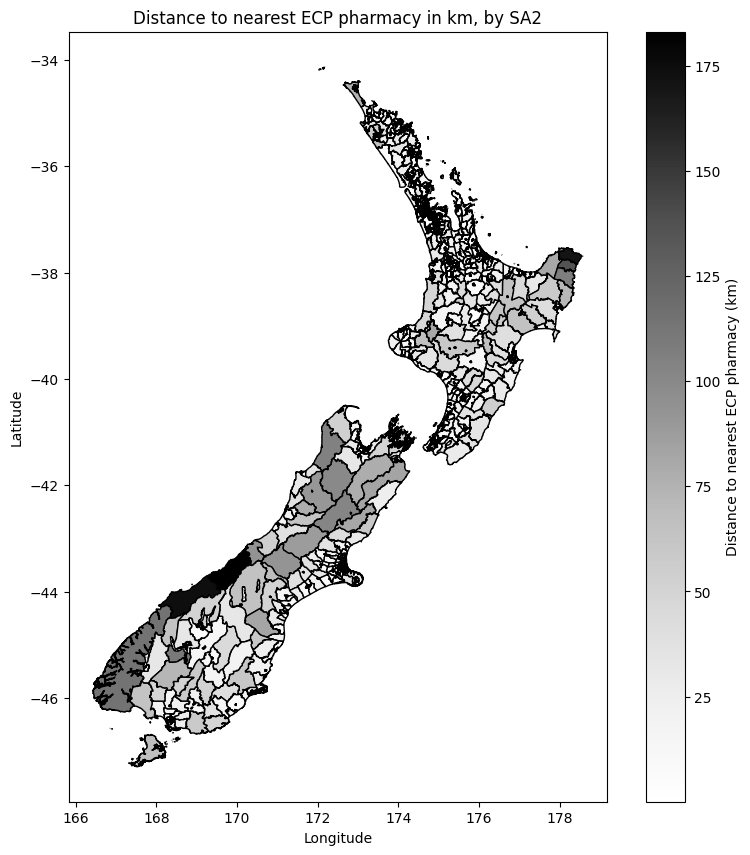

In [28]:
sa2["Distance to nearest ECP pharmacy (km)"] = sa2["Distance to nearest ECP pharmacy (m)"] / 1000
ax = sa2.to_crs(4326).plot("Distance to nearest ECP pharmacy (km)", cmap="Grays", figsize=(10,10), legend=True, edgecolor="black", legend_kwds={"label": "Distance to nearest ECP pharmacy (km)"})
ax.title.set_text("Distance to nearest ECP pharmacy in km, by SA2")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [29]:
pop_by_SA2 = pd.read_csv("2023 population by SA2.csv")
pop_by_SA2 = pd.pivot_table(pop_by_SA2[pop_by_SA2.CEN23_SAB_002 == 22], index="Age", columns="Area", values="OBS_VALUE", aggfunc="sum")
fpop_by_SA2_under_45 = pop_by_SA2.loc[:"40-44 years"].sum()
fpop_by_SA2_under_45.name = "Female_population_15_to_45_years"
fpop_by_SA2_under_45

Area
Abbey Caves-Glenbervie    204.0
Abbotsford                552.0
Acacia Bay                219.0
Addington East            888.0
Addington North             0.0
                          ...  
Ōwairaka East             525.0
Ōwairaka West             786.0
Ōwhata East               618.0
Ōwhata West               660.0
Ōwhiro Bay                435.0
Name: Female_population_15_to_45_years, Length: 2414, dtype: float64

In [30]:
sa2 = sa2.merge(fpop_by_SA2_under_45, left_on="SA22023__1", right_index=True)
sa2

,SA22023_V1,SA22023__1,SA22023__2,LAND_AREA_,AREA_SQ_KM,Shape_Leng,geometry,Distance to nearest ECP pharmacy (m),Travel time to nearest ECP pharmacy (s),Nearest pharmacy name,DHB,openHoursPerWeek,Distance to nearest ECP pharmacy (km),Female_population_15_to_45_years
0,100100,North Cape,North Cape,829.188012,829.188012,416039.151064,"MULTIPOLYGON (((1614055.808 6154067.023, 16141...",73907.0,4065.0,Browns Community Pharmacy Kaitaia,Northland,48.00,73.9070,282.0
1,100200,Rangaunu Harbour,Rangaunu Harbour,274.004295,274.004295,149089.110095,"MULTIPOLYGON (((1624166.328 6127258.658, 16243...",21844.5,1229.9,Browns Community Pharmacy Kaitaia,Northland,48.00,21.8445,393.0
3,100400,Karikari Peninsula,Karikari Peninsula,174.440751,174.440751,140149.099270,"MULTIPOLYGON (((1626838.499 6126965.133, 16270...",20256.9,1563.0,Doubtless Bay Pharmacy,Northland,44.00,20.2569,225.0
4,100500,Tangonge,Tangonge,177.182117,177.182117,101466.900183,"POLYGON ((1623516.265 6119580.907, 1623492.213...",11415.6,892.2,Far North Pharmacy,Northland,42.50,11.4156,225.0
5,100900,Rangitihi,Rangitihi,84.539982,84.539982,60636.302194,"POLYGON ((1629314.862 6117970.968, 1629371.783...",4083.6,240.7,Far North Pharmacy,Northland,42.50,4.0836,153.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,362601,Heidelberg,Heidelberg,1.308968,1.308968,5367.870180,"POLYGON ((1245892.259 4848174.153, 1245922.973...",1823.2,171.2,Baillie and Lewis Pharmacy,Southern,61.00,1.8232,438.0
2375,363001,Clifton-Kew,Clifton-Kew,3.770832,3.770832,11890.253381,"POLYGON ((1243666.689 4847254.124, 1243677.447...",2288.4,211.7,Baillie and Lewis Pharmacy,Southern,61.00,2.2884,378.0
2376,363100,Woodend-Greenhills,Woodend-Greenhills,173.600766,173.600766,166674.352079,"MULTIPOLYGON (((1248612.765 4823630.51, 124866...",15441.7,1496.8,Baillie and Lewis Pharmacy,Southern,61.00,15.4417,102.0
2378,363301,Bluff,Bluff,10.136949,10.290040,23162.004392,"POLYGON ((1244729.237 4827495.819, 1244667.973...",26928.8,1459.0,Baillie and Lewis Pharmacy,Southern,61.00,26.9288,267.0


In [31]:
imd_SA2 = gpd.read_file("SA2_2023_with_weighted_average_IMD18.shp.zip")
imd_SA2

,SA22023_V1,SA22023__1,SA22023__2,LAND_AREA_,AREA_SQ_KM,Shape_Leng,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces,geometry
0,100100,North Cape,North Cape,829.188012,829.188012,4.160392e+05,1134.0,1.0,5568.000000,5657.000000,4968.000000,3171.000000,5446.000000,3552.000000,6076.000000,6142.000000,"MULTIPOLYGON (((1614006.423 6153883.036, 16140..."
1,100200,Rangaunu Harbour,Rangaunu Harbour,274.004295,274.004295,1.490891e+05,2889.0,4.0,5237.006231,5811.634476,4856.084112,3794.280374,4288.727934,2598.958463,5141.264798,5622.019730,"MULTIPOLYGON (((1624166.328 6127258.658, 16241..."
2,100301,Inlets Far North District,Inlets Far North District,0.000000,623.222037,1.349364e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((1625534.345 6096218.852, 16255..."
3,100400,Karikari Peninsula,Karikari Peninsula,174.440751,174.440751,1.401491e+05,1647.0,2.0,5450.828780,5856.259563,5235.881603,4533.936248,2544.624772,4441.194900,5007.848816,5941.721311,"MULTIPOLYGON (((1627513.378 6126695.648, 16274..."
4,100500,Tangonge,Tangonge,177.182117,177.182117,1.014669e+05,2040.0,3.0,4759.502941,5109.614706,4638.917647,3922.147059,3388.979412,3404.920588,4798.617647,5241.555882,"POLYGON ((1622142.241 6120263.153, 1623239.835..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2390,400006,Campbell Island,Campbell Island,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2391,400007,Oceanic Oil Rig Southland,Oceanic Oil Rig Southland,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2392,400008,Oceanic Auckland Islands,Oceanic Auckland Islands,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2393,400009,Auckland Islands,Auckland Islands,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [32]:
sa2 = sa2.join(imd_SA2.drop(columns=['SA22023_V1', 'SA22023__1', 'SA22023__2', 'LAND_AREA_', 'AREA_SQ_KM',
       'Shape_Leng', 'geometry']), how="left")
sa2

,SA22023_V1,SA22023__1,SA22023__2,LAND_AREA_,AREA_SQ_KM,Shape_Leng,geometry,Distance to nearest ECP pharmacy (m),Travel time to nearest ECP pharmacy (s),Nearest pharmacy name,DHB,openHoursPerWeek,Distance to nearest ECP pharmacy (km),Female_population_15_to_45_years,Census_Pop,Count_DZ20,Rank_IMD18,Rank_Emplo,Rank_Incom,Rank_Crime,Rank_Housi,Rank_Healt,Rank_Educa,Rank_Acces
0,100100,North Cape,North Cape,829.188012,829.188012,416039.151064,"MULTIPOLYGON (((1614055.808 6154067.023, 16141...",73907.0,4065.0,Browns Community Pharmacy Kaitaia,Northland,48.00,73.9070,282.0,1134.0,1.0,5568.000000,5657.000000,4968.000000,3171.000000,5446.000000,3552.000000,6076.000000,6142.000000
1,100200,Rangaunu Harbour,Rangaunu Harbour,274.004295,274.004295,149089.110095,"MULTIPOLYGON (((1624166.328 6127258.658, 16243...",21844.5,1229.9,Browns Community Pharmacy Kaitaia,Northland,48.00,21.8445,393.0,2889.0,4.0,5237.006231,5811.634476,4856.084112,3794.280374,4288.727934,2598.958463,5141.264798,5622.019730
3,100400,Karikari Peninsula,Karikari Peninsula,174.440751,174.440751,140149.099270,"MULTIPOLYGON (((1626838.499 6126965.133, 16270...",20256.9,1563.0,Doubtless Bay Pharmacy,Northland,44.00,20.2569,225.0,1647.0,2.0,5450.828780,5856.259563,5235.881603,4533.936248,2544.624772,4441.194900,5007.848816,5941.721311
4,100500,Tangonge,Tangonge,177.182117,177.182117,101466.900183,"POLYGON ((1623516.265 6119580.907, 1623492.213...",11415.6,892.2,Far North Pharmacy,Northland,42.50,11.4156,225.0,2040.0,3.0,4759.502941,5109.614706,4638.917647,3922.147059,3388.979412,3404.920588,4798.617647,5241.555882
5,100900,Rangitihi,Rangitihi,84.539982,84.539982,60636.302194,"POLYGON ((1629314.862 6117970.968, 1629371.783...",4083.6,240.7,Far North Pharmacy,Northland,42.50,4.0836,153.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2374,362601,Heidelberg,Heidelberg,1.308968,1.308968,5367.870180,"POLYGON ((1245892.259 4848174.153, 1245922.973...",1823.2,171.2,Baillie and Lewis Pharmacy,Southern,61.00,1.8232,438.0,1854.0,3.0,5086.378641,4322.406149,5184.961165,4456.559871,3520.524272,5046.786408,5402.951456,2733.339806
2375,363001,Clifton-Kew,Clifton-Kew,3.770832,3.770832,11890.253381,"POLYGON ((1243666.689 4847254.124, 1243677.447...",2288.4,211.7,Baillie and Lewis Pharmacy,Southern,61.00,2.2884,378.0,2847.0,4.0,5450.344573,5364.720759,5284.477345,2813.727081,3701.821918,5066.628030,5863.432034,4104.537408
2376,363100,Woodend-Greenhills,Woodend-Greenhills,173.600766,173.600766,166674.352079,"MULTIPOLYGON (((1248612.765 4823630.51, 124866...",15441.7,1496.8,Baillie and Lewis Pharmacy,Southern,61.00,15.4417,102.0,879.0,1.0,1636.000000,1507.500000,1573.000000,2090.000000,332.000000,2333.000000,3783.000000,5501.000000
2378,363301,Bluff,Bluff,10.136949,10.290040,23162.004392,"POLYGON ((1244729.237 4827495.819, 1244667.973...",26928.8,1459.0,Baillie and Lewis Pharmacy,Southern,61.00,26.9288,267.0,1788.0,2.0,4629.345638,4240.705537,4141.481544,1144.600671,2129.151007,4402.182886,5913.005034,5768.588926


In [33]:
model = smf.ols("Q('Distance to nearest ECP pharmacy (m)') ~ Female_population_15_to_45_years", data=sa2).fit()
display(model.summary())
print(model.pvalues)
model = smf.ols("Q('Distance to nearest ECP pharmacy (m)') ~ Rank_IMD18", data=sa2).fit()
display(model.summary())
print(model.pvalues)
model = smf.ols("Q('Distance to nearest ECP pharmacy (m)') ~ Female_population_15_to_45_years + Rank_IMD18", data=sa2).fit()
display(model.summary())
print(model.pvalues)
model = smf.ols("openHoursPerWeek ~ Female_population_15_to_45_years", data=sa2).fit()
display(model.summary())
print(model.pvalues)
model = smf.ols("openHoursPerWeek ~ Rank_IMD18", data=sa2).fit()
display(model.summary())
print(model.pvalues)
model = smf.ols("openHoursPerWeek ~ Female_population_15_to_45_years + Rank_IMD18", data=sa2).fit()
display(model.summary())
print(model.pvalues)

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     Q('Distance to nearest ECP pharmacy (m)')   R-squared:                       0.105
Model:                                                   OLS   Adj. R-squared:                  0.104
Method:                                        Least Squares   F-statistic:                     249.0
Date:                                       Wed, 02 Jul 2025   Prob (F-statistic):           3.92e-53
Time:                                               15:33:13   Log-Likelihood:                -23405.
No. Observations:                                       2130   AIC:                         4.681e+04
Df Residuals:                                           2128   BIC:                         4.683e+04
Df Model:                                                  1                                         
Covariance Type:                                   nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         1.494e+04    605.792     24.667      0.000    1.38e+04    1.61e+04
Female_population_15_to_45_years   -18.8645      1.195    -15.780      0.000     -21.209     -16.520
==============================================================================
Omnibus:                     2144.152   Durbin-Watson:                   1.349
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           121238.208
Skew:                           4.880   Prob(JB):                         0.00
Kurtosis:                      38.648   Cond. No.                         989.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Intercept                           2.277901e-118
Female_population_15_to_45_years     3.919297e-53
dtype: float64


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     Q('Distance to nearest ECP pharmacy (m)')   R-squared:                       0.002
Model:                                                   OLS   Adj. R-squared:                  0.001
Method:                                        Least Squares   F-statistic:                     3.756
Date:                                       Wed, 02 Jul 2025   Prob (F-statistic):             0.0528
Time:                                               15:33:13   Log-Likelihood:                -22481.
No. Observations:                                       2040   AIC:                         4.497e+04
Df Residuals:                                           2038   BIC:                         4.498e+04
Df Model:                                                  1                                         
Covariance Type:                                   nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7689.2323    687.489     11.185      0.000    6340.978    9037.486
Rank_IMD18    -0.3866      0.199     -1.938      0.053      -0.778       0.005
==============================================================================
Omnibus:                     2126.191   Durbin-Watson:                   1.193
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           126756.246
Skew:                           5.153   Prob(JB):                         0.00
Kurtosis:                      40.216   Cond. No.                     7.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Intercept     3.163258e-28
Rank_IMD18    5.275097e-02
dtype: float64


<class 'statsmodels.iolib.summary.Summary'>
"""
                                        OLS Regression Results                                       
=====================================================================================================
Dep. Variable:     Q('Distance to nearest ECP pharmacy (m)')   R-squared:                       0.105
Model:                                                   OLS   Adj. R-squared:                  0.104
Method:                                        Least Squares   F-statistic:                     119.3
Date:                                       Wed, 02 Jul 2025   Prob (F-statistic):           9.97e-50
Time:                                               15:33:13   Log-Likelihood:                -22370.
No. Observations:                                       2040   AIC:                         4.475e+04
Df Residuals:                                           2037   BIC:                         4.476e+04
Df Model:                                                  2                                         
Covariance Type:                                   nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                         1.552e+04    827.836     18.742      0.000    1.39e+04    1.71e+04
Female_population_15_to_45_years   -18.5580      1.212    -15.312      0.000     -20.935     -16.181
Rank_IMD18                          -0.2281      0.189     -1.205      0.228      -0.599       0.143
==============================================================================
Omnibus:                     2113.490   Durbin-Watson:                   1.358
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           136748.233
Skew:                           5.059   Prob(JB):                         0.00
Kurtosis:                      41.813   Cond. No.                     9.26e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.26e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

...

Intercept                           0.000000
Female_population_15_to_45_years    0.000038
dtype: float64


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       openHoursPerWeek   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     10.49
Date:                Wed, 02 Jul 2025   Prob (F-statistic):            0.00122
Time:                        15:33:13   Log-Likelihood:                -7681.5
No. Observations:                2040   AIC:                         1.537e+04
Df Residuals:                    2038   BIC:                         1.538e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     52.9294      0.486    108.927      0.000      51.976      53.882
Rank_IMD18    -0.0005      0.000     -3.239      0.001      -0.001      -0.000
==============================================================================
Omnibus:                      727.958   Durbin-Watson:                   1.697
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2314.422
Skew:                           1.823   Prob(JB):                         0.00
Kurtosis:                       6.733   Cond. No.                     7.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Intercept     0.000000
Rank_IMD18    0.001217
dtype: float64


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       openHoursPerWeek   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     14.44
Date:                Wed, 02 Jul 2025   Prob (F-statistic):           5.94e-07
Time:                        15:33:13   Log-Likelihood:                -7672.4
No. Observations:                2040   AIC:                         1.535e+04
Df Residuals:                    2037   BIC:                         1.537e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           51.3051      0.615     83.408      0.000      50.099      52.511
Female_population_15_to_45_years     0.0039      0.001      4.277      0.000       0.002       0.006
Rank_IMD18                          -0.0005      0.000     -3.482      0.001      -0.001      -0.000
==============================================================================
Omnibus:                      716.633   Durbin-Watson:                   1.722
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2233.318
Skew:                           1.802   Prob(JB):                         0.00
Kurtosis:                       6.645   Cond. No.                     9.26e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.26e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Intercept                           0.000000
Female_population_15_to_45_years    0.000020
Rank_IMD18                          0.000508
dtype: float64


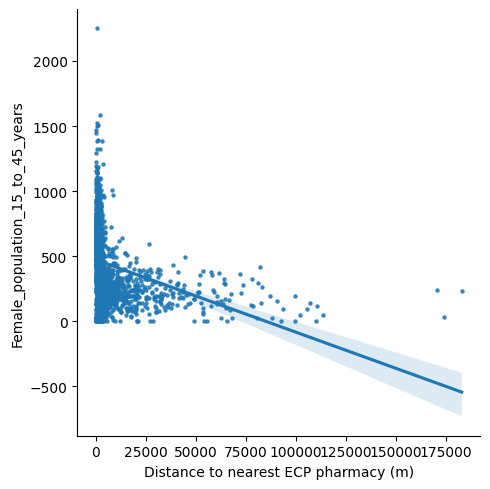

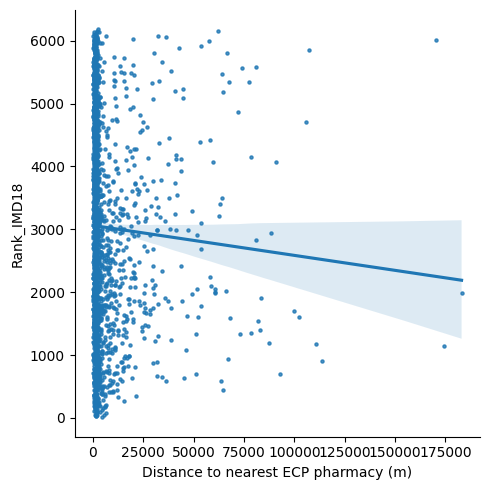

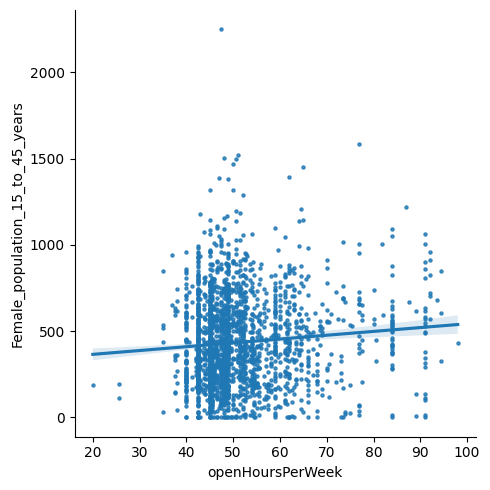

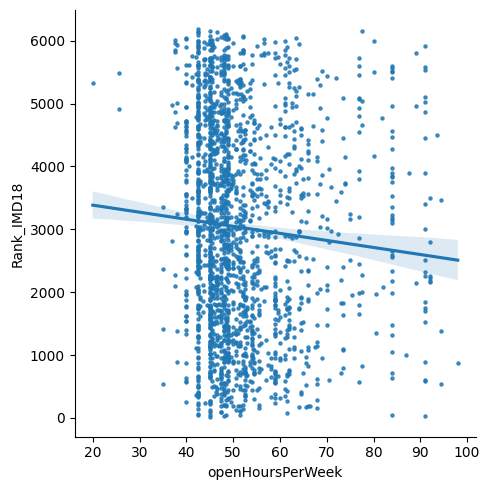

In [60]:
import seaborn as sns
sns.lmplot(x='Distance to nearest ECP pharmacy (m)',y='Female_population_15_to_45_years',data=sa2, scatter_kws={"s": 5})
sns.lmplot(x='Distance to nearest ECP pharmacy (m)',y='Rank_IMD18',data=sa2, scatter_kws={"s": 5})
sns.lmplot(x='openHoursPerWeek',y='Female_population_15_to_45_years',data=sa2, scatter_kws={"s": 5})
sns.lmplot(x='openHoursPerWeek',y='Rank_IMD18',data=sa2, scatter_kws={"s": 5})